# VisXAI: Sequence Path Demo

This notebook walks through VisXAI's fully-working **sequence** pipeline:
tokenize a SMILES string &rarr; train a tiny attention model on a
synthetic task &rarr; explain a prediction with `AttentionExplainer` &rarr;
see **both atom-level and (partial) bond-level** attribution on a colored
2D structure. See `CAPABILITIES.md` at the repo root for the full
flowchart and architecture notes.

Unlike the tree-path demo's classifier, the tiny model here is **actually
trained** (a real gradient-descent loop, not just randomly initialized
weights) on a small synthetic label, so the attention pattern shown later
is at least honestly earned.

In [1]:
from types import SimpleNamespace

import torch
from IPython.display import SVG, display
from rdkit import Chem

from visxai.explainers.attention import AttentionExplainer
from visxai.features.sequences import generate_sequence_representation
from visxai.models.pytorch_wrapper import PyTorchSequenceWrapper
from visxai.visualizers.rdkit_2d import RDKitSVGVisualizer

## The synthetic task: "does this molecule contain an aromatic ring?"

A chemically well-defined, RDKit-computable label:
`any(atom.GetIsAromatic() for atom in mol.GetAtoms())`.

The tree-path demo's 5-molecule set only gives a thin 2-positive/
3-negative split &mdash; not enough signal for a gradient-descent loop to
show honest convergence. This demo expands to 12 molecules (still tiny,
still fully hardcoded, no external data), keeping the original 5 and
adding 7 more chosen for balance and to sharpen what the model actually
has to learn:

- **pyridine** (`c1ccncc1`) &mdash; aromatic, an aromatic N-containing ring
- **ibuprofen** (`CC(C)Cc1ccc(cc1)C(C)C(=O)O`) &mdash; aromatic (its bond
  coverage is already documented in `CAPABILITIES.md`)
- **hexane** (`CCCCCC`) &mdash; non-aromatic, no ring at all
- **cyclohexane** (`C1CCCCC1`) &mdash; non-aromatic *but has a ring* &mdash;
  this is the key contrast case, so the model can't just learn "contains
  any ring token" as a shortcut
- **toluene** (`Cc1ccccc1`) &mdash; aromatic
- **acetamide** (`CC(=O)N`) &mdash; non-aromatic
- **naphthalene** (`c1ccc2ccccc2c1`) &mdash; aromatic (fused rings)

This gives a balanced 6 aromatic / 6 non-aromatic split. Aspirin stays in
the training set (not held out) but is used for the explanation
walkthrough afterward.

In [2]:
_TRAIN_SMILES = {
    "ethanol": "CCO",
    "benzene": "c1ccccc1",
    "acetic_acid": "CC(=O)O",
    "pyrrolidine": "CN1CCCC1",
    "aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "pyridine": "c1ccncc1",
    "ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "hexane": "CCCCCC",
    "cyclohexane": "C1CCCCC1",
    "toluene": "Cc1ccccc1",
    "acetamide": "CC(=O)N",
    "naphthalene": "c1ccc2ccccc2c1",
}

mol_reps = {name: generate_sequence_representation(smi) for name, smi in _TRAIN_SMILES.items()}
labels = {
    name: float(any(atom.GetIsAromatic() for atom in rep.mol.GetAtoms()))
    for name, rep in mol_reps.items()
}
print(f"{sum(labels.values()):.0f} aromatic / {len(labels)} total")
for name, label in labels.items():
    print(f"  {name:15s} aromatic={bool(label)}")

6 aromatic / 12 total
  ethanol         aromatic=False
  benzene         aromatic=True
  acetic_acid     aromatic=False
  pyrrolidine     aromatic=False
  aspirin         aromatic=True
  pyridine        aromatic=True
  ibuprofen       aromatic=True
  hexane          aromatic=False
  cyclohexane     aromatic=False
  toluene         aromatic=True
  acetamide       aromatic=False
  naphthalene     aromatic=True


## Model + training loop

A small multi-layer, multi-head self-attention classifier over token ids
&mdash; same shape as the one used in `tests/test_attention.py`, but
redefined here (that class is test-private) and, critically, **actually
trained** below rather than left at random initialization.

In [3]:
class TinyAttentionClassifier(torch.nn.Module):
    """A minimal multi-layer, multi-head self-attention model over token ids."""

    def __init__(self, vocab_size=64, embed_dim=8, num_heads=2, num_layers=2):
        super().__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embed_dim)
        self.attn_layers = torch.nn.ModuleList(
            [
                torch.nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
                for _ in range(num_layers)
            ]
        )
        self.linear = torch.nn.Linear(embed_dim, 1)

    def forward(self, input_ids, attention_mask, output_attentions=False):
        x = self.embedding(input_ids)
        key_padding_mask = attention_mask == 0
        attentions = []
        for layer in self.attn_layers:
            x, attn_weights = layer(
                x, x, x,
                key_padding_mask=key_padding_mask,
                need_weights=True,
                average_attn_weights=False,
            )
            attentions.append(attn_weights)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        logits = self.linear(pooled)
        if output_attentions:
            return SimpleNamespace(logits=logits, attentions=tuple(attentions))
        return SimpleNamespace(logits=logits)


torch.manual_seed(0)
model = TinyAttentionClassifier()

In [4]:
# Pad token_ids/attention_mask to a common length across the training batch.
names = list(_TRAIN_SMILES.keys())
max_len = max(len(mol_reps[n].token_ids) for n in names)
PAD_ID = 0  # _VOCAB["[PAD]"] == 0

input_ids = torch.zeros((len(names), max_len), dtype=torch.long)
attention_mask = torch.zeros((len(names), max_len), dtype=torch.long)
for i, name in enumerate(names):
    ids = mol_reps[name].token_ids
    mask = mol_reps[name].attention_mask
    input_ids[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)
    attention_mask[i, : len(mask)] = torch.tensor(mask, dtype=torch.long)

label_tensor = torch.tensor([[labels[n]] for n in names], dtype=torch.float)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = torch.nn.BCEWithLogitsLoss()

model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    loss = loss_fn(out.logits, label_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}  loss={loss.item():.4f}")
print(f"epoch {epoch:3d}  loss={loss.item():.4f}  (final)")

epoch   0  loss=0.6664
epoch  10  loss=0.1564
epoch  20  loss=0.0005
epoch  30  loss=0.0000
epoch  40  loss=0.0000
epoch  50  loss=0.0000
epoch  60  loss=0.0000
epoch  70  loss=0.0000
epoch  80  loss=0.0000
epoch  90  loss=0.0000
epoch  99  loss=0.0000  (final)


### Sanity check: did the model actually learn anything?

Predictions across the 12 training molecules should spread out (not sit
at a constant ~0.5) and roughly track the true aromatic/non-aromatic
split &mdash; confirming the training loop is genuinely learning, not just
running.

In [5]:
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(input_ids=input_ids, attention_mask=attention_mask).logits)

for name, prob in zip(names, probs.squeeze(-1).tolist()):
    print(f"  {name:15s} P(aromatic)={prob:.3f}  true={bool(labels[name])}")

  ethanol         P(aromatic)=0.000  true=False
  benzene         P(aromatic)=1.000  true=True
  acetic_acid     P(aromatic)=0.000  true=False
  pyrrolidine     P(aromatic)=0.000  true=False
  aspirin         P(aromatic)=1.000  true=True
  pyridine        P(aromatic)=1.000  true=True
  ibuprofen       P(aromatic)=1.000  true=True
  hexane          P(aromatic)=0.000  true=False
  cyclohexane     P(aromatic)=0.000  true=False
  toluene         P(aromatic)=1.000  true=True
  acetamide       P(aromatic)=0.000  true=False
  naphthalene     P(aromatic)=1.000  true=True


## Explaining aspirin

Aspirin is used here because it's already verified elsewhere in the repo
to show **partial bond-level attribution**: only 2 of its 13 bonds (the
two C=O double bonds) carry an explicit character in the SMILES string, so
only those 2 can receive a `bond_scores` entry &mdash; every other bond
(including the whole aromatic ring) is implicit and has nothing to
measure. See `CAPABILITIES.md`'s "Sequence path" section for the full
explanation of why bond coverage is inherently partial (~7-27% on real
drug molecules).

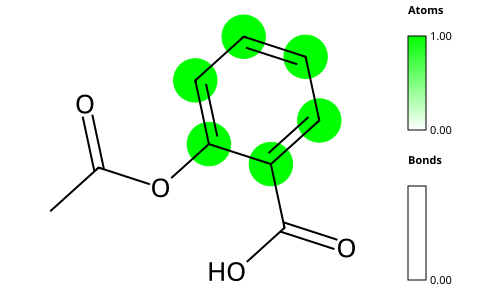

atoms scored: 13 / 13
bonds scored: 2 / 13
bond_scores: {1: 2.2649002465180423e-11, 10: 2.2649002465180423e-11}


In [6]:
wrapper = PyTorchSequenceWrapper(model)
mol_rep = mol_reps["aspirin"]

explanation = AttentionExplainer().explain(wrapper, mol_rep)
svg = RDKitSVGVisualizer().visualize(mol_rep, explanation)
display(SVG(svg))

print(f"atoms scored: {len(explanation.atom_scores)} / {mol_rep.mol.GetNumAtoms()}")
print(f"bonds scored: {len(explanation.bond_scores)} / {mol_rep.mol.GetNumBonds()}")
print("bond_scores:", explanation.bond_scores)

Every atom gets a score (dense &mdash; `atom_scores` always covers all
atoms, default `0.0`), but only the sparse subset of bonds with an
explicit SMILES character get a `bond_scores` entry at all; unattributed
bonds are **omitted entirely, not zero-filled**, so "no character to
measure" stays visually distinct from "measured, came out zero."

### Comparing aggregation strategies

`AttentionExplainer` supports two aggregation strategies. Here's the same
molecule explained with `"rollout"` (full attention-rollout across all
layers) instead of the default `"last_layer_mean_heads"`:

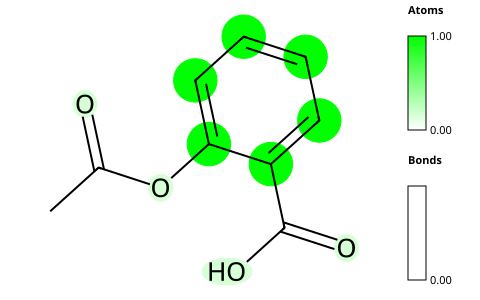

bonds scored (rollout): 2 / 13


In [7]:
rollout_explanation = AttentionExplainer(strategy="rollout").explain(wrapper, mol_rep)
display(SVG(RDKitSVGVisualizer().visualize(mol_rep, rollout_explanation)))
print(f"bonds scored (rollout): {len(rollout_explanation.bond_scores)} / {mol_rep.mol.GetNumBonds()}")

## Next steps

- The tokenizer used here (`default_smiles_tokenizer`) is VisXAI's
  built-in reference scheme &mdash; it's only valid because the toy model
  above was trained on exactly that scheme. To explain a *real* pretrained
  checkpoint (e.g. an actual ChemBERTa), you'd plug in that model's own
  tokenizer via the `SMILESTokenizer` protocol in `features/sequences.py`
  (see the architecture principle in `CLAUDE.md`) &mdash; out of scope for
  this first-pass demo.
- The graph (PyTorch Geometric) path now has its own demo,
  `graph_demo.ipynb` &mdash; it trains a small message-passing GNN on this
  same aromaticity task and explains it with both
  `IntegratedGradientsExplainer` and `GradCAMExplainer`.
- `models/hf_wrapper.py` (a convenience loader for real pretrained HF
  checkpoints) also doesn't exist yet &mdash; not blocking, since any model
  satisfying the `forward(input_ids, attention_mask)` calling convention
  already works with `PyTorchSequenceWrapper` today, as shown above.